# ¿Cuánto vale la promesa de pago de tu contraparte?
### Demo en vivo · CVA, DVA y *machine learning* sobre la TIIE de Fondeo

### Maurilio Patiño García
**Universidad Anáhuac — Maestría en Administración de Riesgos**

Vamos a construir, de cero y en vivo, la cadena completa: simular la curva mexicana, medir la
exposición, ponerle precio al riesgo de contraparte, ver su espejo (DVA), netearlos, y al final
reemplazar todo el motor por un modelo que responde en microsegundos.

> **Simplificaciones de la demo:** curva plana al nivel de la TIIE de Fondeo y pagos trimestrales.
> Con la curva completa de Valmer y la malla fina, la tesis da **5.55 bps** para este mismo *swap*.

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (11, 4.2), 'axes.grid': True, 'grid.alpha': .25})

# --- G2++ calibrado a swaptions ATM (tesis, 24-mar-2026, datos Valmer) ---
a, b   = 0.148849, 0.982642      # reversión: factor lento (nivel) / rápido (pendiente)
sigma, eta = 0.026973, 0.062209  # volatilidades
rho    = -0.913918               # correlación entre factores
f0, R  = 0.0710, 0.25            # nivel TIIE de Fondeo | recuperación (emergentes)
Noc    = 10_000_000              # nocional: 10 MM MXN
T, delta = 5.0, 0.25             # swap payer 5Y, pagos trimestrales

pay = np.arange(delta, T + 1e-9, delta)   # fechas de pago
mon = pay[:-1]                            # fechas de monitoreo
M, dt = len(pay), delta
print(f"Swap payer {T:.0f}Y · nocional {Noc:,} MXN · {M} pagos trimestrales")

Swap payer 5Y · nocional 10,000,000 MXN · 20 pagos trimestrales


---
## 1 · Simular el futuro
$r(t) = x(t) + y(t) + \varphi(t)$: dos factores gaussianos correlacionados. El esquema es **exacto**
(sin error de discretización): el único error es el de Monte Carlo.

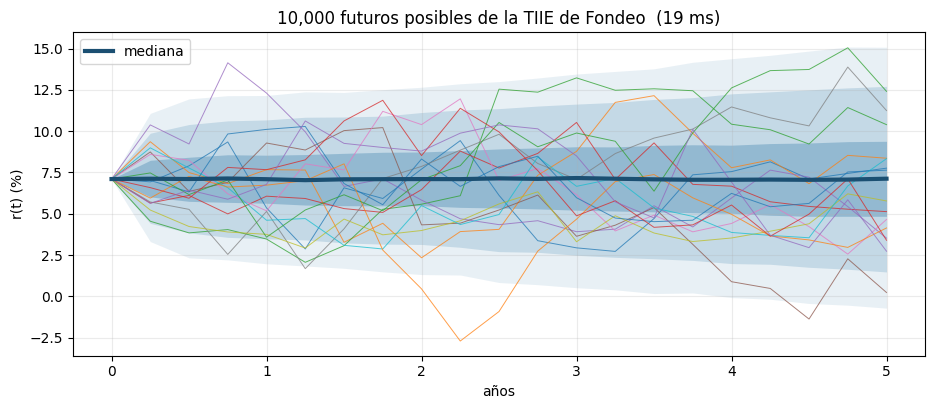

In [2]:
def simular(N=10_000, seed=42):
    rng = np.random.default_rng(seed)
    x = np.zeros((N, M+1)); y = np.zeros((N, M+1))
    sx = sigma*np.sqrt((1-np.exp(-2*a*dt))/(2*a))
    sy = eta  *np.sqrt((1-np.exp(-2*b*dt))/(2*b))
    for i in range(M):
        z1 = rng.standard_normal(N)
        z2 = rho*z1 + np.sqrt(1-rho**2)*rng.standard_normal(N)
        x[:, i+1] = x[:, i]*np.exp(-a*dt) + sx*z1
        y[:, i+1] = y[:, i]*np.exp(-b*dt) + sy*z2
    return x, y

t0 = time.perf_counter(); x, y = simular(); t_sim = time.perf_counter() - t0
r, tt = x + y + f0, np.concatenate([[0.0], pay])

fig, ax = plt.subplots()
for q, al in [(1, .10), (5, .18), (25, .30)]:
    ax.fill_between(tt, np.percentile(100*r, q, axis=0), np.percentile(100*r, 100-q, axis=0),
                    color='#2471a3', alpha=al, lw=0)
ax.plot(tt, 100*r[:15].T, lw=.7, alpha=.75)
ax.plot(tt, np.median(100*r, axis=0), color='#1b4f72', lw=3, label='mediana')
ax.set(xlabel='años', ylabel='r(t) (%)', title=f'10,000 futuros posibles de la TIIE de Fondeo  ({t_sim*1000:.0f} ms)')
ax.legend(); plt.show()

> **Lectura.** El abanico se abre con la raíz del tiempo: a 5 años la banda del 90% cubre casi
> 10 puntos porcentuales. Eso **no** es un pronóstico de tasas: es la incertidumbre que el mercado
> le pone precio hoy, bajo la medida $\mathbb{Q}$. Las trayectorias individuales muestran la
> firma de los dos factores — el vaivén rápido montado sobre la deriva lenta del nivel.
>
> **Y aquí está el truco de toda la clase:** estas trayectorias se simulan **una sola vez**. Todo
> lo que sigue —exposición, CVA, DVA, escenarios, entrenamiento del modelo— se calcula reusando
> este mismo cubo. *Simular una vez, valuar todo.*

---
## 2 · Valuar el swap en cada futuro
Fórmula cerrada del bono cupón cero del G2++. De aquí sale el **cubo de MtM**: cada trayectoria,
cada fecha, un valor.

In [3]:
def B(k, tau): return (1 - np.exp(-k*tau)) / k

def Vv(tau):                       # varianza integrada del G2++ (Brigo–Mercurio)
    tau = np.maximum(tau, 0)
    return ((sigma**2/a**2)*(tau + (2/a)*np.exp(-a*tau) - (1/(2*a))*np.exp(-2*a*tau) - 3/(2*a))
          + (eta**2 /b**2)*(tau + (2/b)*np.exp(-b*tau) - (1/(2*b))*np.exp(-2*b*tau) - 3/(2*b))
          + 2*rho*(sigma*eta/(a*b))*(tau + (np.exp(-a*tau)-1)/a + (np.exp(-b*tau)-1)/b
                                         - (np.exp(-(a+b)*tau)-1)/(a+b)))

def P(ti, Tj, xi, yi):             # P(t,T) con corrección de convexidad
    tau = Tj - ti
    return np.exp(-f0*tau + 0.5*(Vv(tau) - Vv(Tj) + Vv(ti)) - B(a,tau)*xi - B(b,tau)*yi)

P0    = np.array([P(0, Tj, 0, 0) for Tj in pay])
K_atm = (1 - P0[-1]) / (delta * P0.sum())          # tasa fija ATM
DF    = np.exp(-f0 * mon)

t0 = time.perf_counter()
Pn_l, ann_l = [], []
for j, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, x[:, j], y[:, j]) for Tj in rem], axis=1)
    Pn_l.append(Pm[:, -1]); ann_l.append(delta * Pm.sum(axis=1))
t_val = time.perf_counter() - t0

V   = [Noc*((1 - Pn) - K_atm*an) for Pn, an in zip(Pn_l, ann_l)]   # MtM por fecha
EE  = np.array([np.maximum( v, 0).mean() for v in V])              # exposición esperada
ENE = np.array([np.maximum(-v, 0).mean() for v in V])              # exposición negativa
PFE = np.array([np.percentile(np.maximum(v, 0), 97.5) for v in V])
print(f"Tasa fija ATM: {K_atm:.4%}   |   cubo de MtM valuado en {t_val*1000:.0f} ms")

Tasa fija ATM: 7.1634%   |   cubo de MtM valuado en 50 ms


> **Lectura.** La tasa fija ATM sale en **7.16%**, ligeramente por debajo del nivel de la curva
> (7.10%) por la convexidad del G2++. Con esa tasa el *swap* vale cero hoy — pero solo hoy.
>
> Valuar 10,000 trayectorias × 19 fechas × todos los flujos toma **decenas de milisegundos**.
> Retengan ese orden de magnitud: es el costo que más adelante multiplicaremos por 795 operaciones
> y por 40 perturbaciones.

### El momento clave: la MISMA distribución, partida por el cero
En el pico de exposición, miramos el valor del *swap* sobre las 10,000 trayectorias. **La mitad
derecha es el CVA; la mitad izquierda es el DVA.** No son dos cálculos distintos: son dos lados de
la misma moneda.

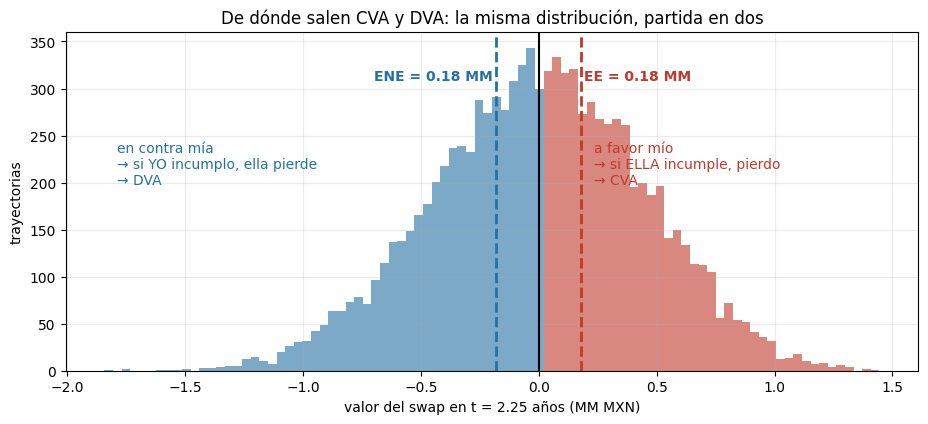

In [4]:
j  = int(EE.argmax()); Vp = V[j]/1e6
fig, ax = plt.subplots(figsize=(11, 4.4))
n, bins, patches = ax.hist(Vp, bins=90, edgecolor='none')
for p, bl in zip(patches, bins[:-1]):
    p.set_facecolor('#c0392b' if bl >= 0 else '#2471a3'); p.set_alpha(.6)
ax.axvline(0, color='k', lw=1.5)
ax.axvline( EE[j]/1e6, color='#c0392b', ls='--', lw=2)
ax.axvline(-ENE[j]/1e6, color='#2471a3', ls='--', lw=2)
ax.text( EE[j]/1e6*1.08, max(n)*.90, f'EE = {EE[j]/1e6:.2f} MM', color='#c0392b', fontweight='bold')
ax.text(-ENE[j]/1e6*1.08, max(n)*.90, f'ENE = {ENE[j]/1e6:.2f} MM', color='#2471a3',
        fontweight='bold', ha='right')
ax.text(.62, .55, 'a favor mío\n→ si ELLA incumple, pierdo\n→ CVA', transform=ax.transAxes,
        color='#c0392b', fontsize=10)
ax.text(.06, .55, 'en contra mía\n→ si YO incumplo, ella pierde\n→ DVA', transform=ax.transAxes,
        color='#2471a3', fontsize=10)
ax.set(xlabel=f'valor del swap en t = {mon[j]:.2f} años (MM MXN)', ylabel='trayectorias',
       title='De dónde salen CVA y DVA: la misma distribución, partida en dos')
plt.show()

> ### Esta es la lámina más importante de la clase
>
> **Un solo objeto, dos riesgos.** El *swap* está *at-the-money*, así que la distribución está
> centrada en cero: es casi igual de probable que valga a mi favor o en mi contra.
>
> - **Lado rojo** (a mi favor): ella me debe. Si incumple, **yo** pierdo → esto es el **CVA**.
> - **Lado azul** (en mi contra): yo le debo. Si incumplo, **ella** pierde → esto es el **DVA**.
>
> EE y ENE son simplemente **la media de cada lado**. Por eso el DVA no requiere un modelo nuevo:
> es la misma simulación, el mismo cubo, leído desde la otra silla. Y por eso son casi iguales
> (0.18 MM cada uno) — la asimetría del precio final vendrá **solo** de los *spreads* de crédito.
>
> Noten también que ambos lados nacen de un $\max(\cdot,0)$. Esa no-linealidad es la razón por la
> que el CVA de un portafolio **no** es la suma de los CVA individuales — y el origen de casi toda
> la dificultad técnica de la tesis.

### Promediando cada lado en todas las fechas: los dos perfiles

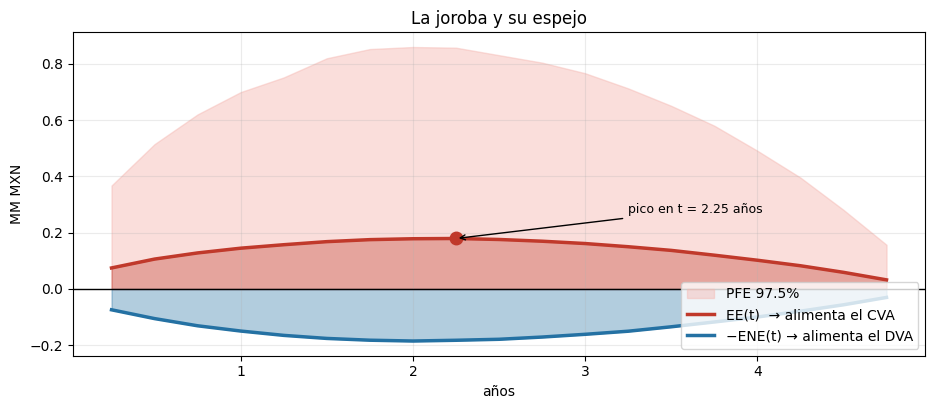

In [5]:
fig, ax = plt.subplots()
ax.fill_between(mon, 0, PFE/1e6, color='#f5b7b1', alpha=.45, label='PFE 97.5%')
ax.fill_between(mon, 0,  EE/1e6, color='#c0392b', alpha=.35)
ax.fill_between(mon, 0, -ENE/1e6, color='#2471a3', alpha=.35)
ax.plot(mon,  EE/1e6, color='#c0392b', lw=2.5, label='EE(t)  → alimenta el CVA')
ax.plot(mon, -ENE/1e6, color='#2471a3', lw=2.5, label='−ENE(t) → alimenta el DVA')
ax.axhline(0, color='k', lw=1)
ax.plot(mon[j], EE[j]/1e6, 'o', ms=9, color='#c0392b')
ax.annotate(f'pico en t = {mon[j]:.2f} años', xy=(mon[j], EE[j]/1e6), xytext=(mon[j]+1, EE[j]/1e6*1.5),
            arrowprops=dict(arrowstyle='->'), fontsize=9)
ax.set(xlabel='años', ylabel='MM MXN', title='La joroba y su espejo')
ax.legend(loc='lower right'); plt.show()

> **Lectura.** La **joroba** es la firma del CVA en un *swap*: la exposición crece porque la
> incertidumbre sobre las tasas se acumula, y luego cae porque quedan menos flujos por intercambiar
> (*pull-to-par*). El pico llega alrededor de **T/3**, no al final.
>
> Consecuencia práctica: **el riesgo de contraparte no está donde la intuición lo pone.** No es
> máximo al vencimiento, sino en el primer tercio de la vida de la operación. Ahí es donde conviene
> vigilar los límites de crédito.
>
> La PFE (banda rosa) llega al 97.5%: es el "peor caso razonable" que las mesas usan para fijar
> líneas, y su pico llega **más tarde** que el de la EE porque la cola derecha se ensancha con el
> horizonte.

---
## 3 · Ponerle precio: CVA, DVA y el neteo bilateral
$$\mathrm{CVA} = (1-R)\sum_i \mathrm{EE}(t_i)\,\Delta\mathrm{PD}(t_i)\,\mathrm{DF}(t_i)
\qquad
\mathrm{DVA} = (1-R)\sum_i \mathrm{ENE}(t_i)\,\Delta\mathrm{PD}^{\text{propia}}(t_i)\,\mathrm{DF}(t_i)$$

La única diferencia entre ambos: **qué perfil usas y de quién es el *spread* de crédito.**

In [6]:
def xva_bps(perfil, cds_bps):
    lam = cds_bps/1e4/(1 - R)                        # intensidad de default
    Q   = np.exp(-lam * mon)                         # curva de supervivencia
    dPD = -np.diff(np.concatenate([[1.0], Q]))       # probabilidad marginal
    return (1 - R) * np.sum(perfil * dPD * DF) / Noc * 1e4

cds_ella, cds_yo = 150.0, 80.0                       # ¡cámbienlos y vuelvan a correr!

cva  = xva_bps(EE,  cds_ella)
dva  = xva_bps(ENE, cds_yo)
bcva = dva - cva

print(f"  CVA  (ella, CDS {cds_ella:>5.0f} bps) = {cva:6.2f} bps = {cva/1e4*Noc:>10,.0f} MXN")
print(f"  DVA  (yo,   CDS {cds_yo:>5.0f} bps) = {dva:6.2f} bps = {dva/1e4*Noc:>10,.0f} MXN")
print(f"  {'-'*58}")
print(f"  BCVA = DVA − CVA           = {bcva:+6.2f} bps = {bcva/1e4*Noc:>+10,.0f} MXN")
print(f"\n  → {'Yo soy el riesgoso: el ajuste juega a mi favor.' if bcva > 0 else 'Ella es la riesgosa: el ajuste me cuesta a mí.'}")

  CVA  (ella, CDS   150 bps) =   7.65 bps =      7,650 MXN
  DVA  (yo,   CDS    80 bps) =   4.21 bps =      4,214 MXN
  ----------------------------------------------------------
  BCVA = DVA − CVA           =  -3.44 bps =     -3,436 MXN

  → Ella es la riesgosa: el ajuste me cuesta a mí.


> **Lectura.** Los perfiles eran casi simétricos, pero el precio **no** lo es: el CVA casi duplica
> al DVA. La única causa es el crédito — ella cotiza a 150 bps y nosotros a 80.
>
> El **BCVA de −3.44 bps** (≈ 3,400 pesos sobre 10 MM) es el ajuste neto. En una cotización real,
> esos 3.4 bps salen del margen del *trader*: o los absorbe, o se los carga al cliente.
>
> El DVA tiene una interpretación incómoda que vale la pena decir en voz alta: **es una ganancia
> contable que aumenta cuando mi propio crédito se deteriora.** Contablemente correcto bajo IFRS 13,
> pero imposible de monetizar salvo incumpliendo. Por eso Basilea lo excluye del capital regulatorio
> y por eso esta tesis se queda en CVA unilateral.

### ¿Y luego? Se netean — y quién gana depende de quién es más riesgoso
Recorremos **mi** *spread* de crédito de 0 a 400 bps dejando fijo el de ella: hay un punto de
cruce donde el ajuste bilateral cambia de signo.

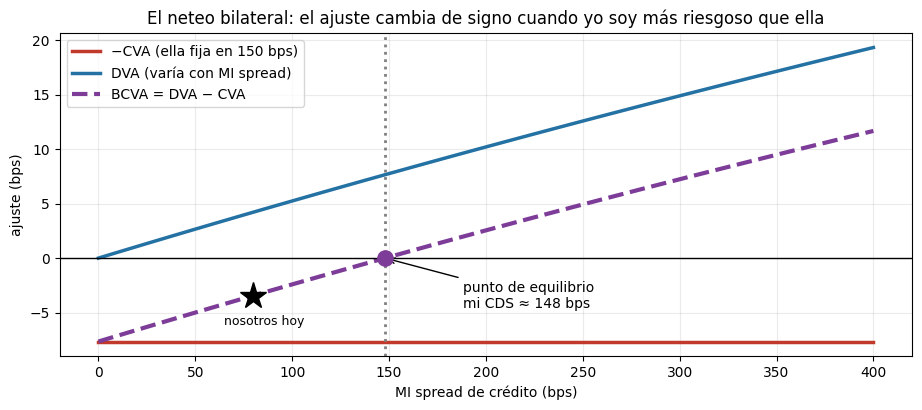

Por debajo de 148 bps el ajuste neto me cuesta; por encima, juega a mi favor.


In [7]:
spreads_yo = np.linspace(0, 400, 60)
cvas = np.full_like(spreads_yo, cva)
dvas = np.array([xva_bps(ENE, s) for s in spreads_yo])
bcvas = dvas - cvas

fig, ax = plt.subplots()
ax.plot(spreads_yo, -cvas, color='#c0392b', lw=2.5, label=f'−CVA (ella fija en {cds_ella:.0f} bps)')
ax.plot(spreads_yo,  dvas, color='#2471a3', lw=2.5, label='DVA (varía con MI spread)')
ax.plot(spreads_yo, bcvas, color='#7d3c98', lw=3, ls='--', label='BCVA = DVA − CVA')
ax.axhline(0, color='k', lw=1)
cruce = np.interp(0, bcvas, spreads_yo)
ax.axvline(cruce, color='gray', ls=':', lw=2)
ax.plot(cruce, 0, 'o', ms=11, color='#7d3c98', zorder=5)
ax.annotate(f'punto de equilibrio\nmi CDS ≈ {cruce:.0f} bps', xy=(cruce, 0), xytext=(cruce+40, -cva*0.6),
            arrowprops=dict(arrowstyle='->'), fontsize=10)
ax.plot(cds_yo, bcva, '*', ms=20, color='k', zorder=5)
ax.annotate('nosotros hoy', xy=(cds_yo, bcva), xytext=(cds_yo-15, bcva-cva*0.35), fontsize=9)
ax.set(xlabel='MI spread de crédito (bps)', ylabel='ajuste (bps)',
       title='El neteo bilateral: el ajuste cambia de signo cuando yo soy más riesgoso que ella')
ax.legend(loc='upper left'); plt.show()
print(f"Por debajo de {cruce:.0f} bps el ajuste neto me cuesta; por encima, juega a mi favor.")

> **Lectura.** Aquí está la respuesta al "¿y luego, se netean o qué?".
>
> Con el CDS de ella **fijo**, movemos el **mío**. El BCVA (línea morada) cruza el cero en
> ≈ **148 bps**, que es justo el *spread* de ella: **el ajuste bilateral se anula cuando ambas
> partes tienen el mismo riesgo de crédito.** Tiene sentido — dos contrapartes igualmente riesgosas
> se cobran lo mismo mutuamente.
>
> - A la izquierda del cruce (nuestro caso, la estrella): **soy el más sólido**, así que el ajuste
>   me cuesta.
> - A la derecha: **yo soy el riesgoso**, y el neteo juega a mi favor.
>
> Esto es negociación real: cuando dos bancos discuten el precio de un *swap*, están discutiendo
> exactamente esta diferencia.

---
## 4 · El mismo swap, seis contrapartes
Idéntico instrumento, idéntico nocional. Lo único que cambia es **con quién** lo firmas.

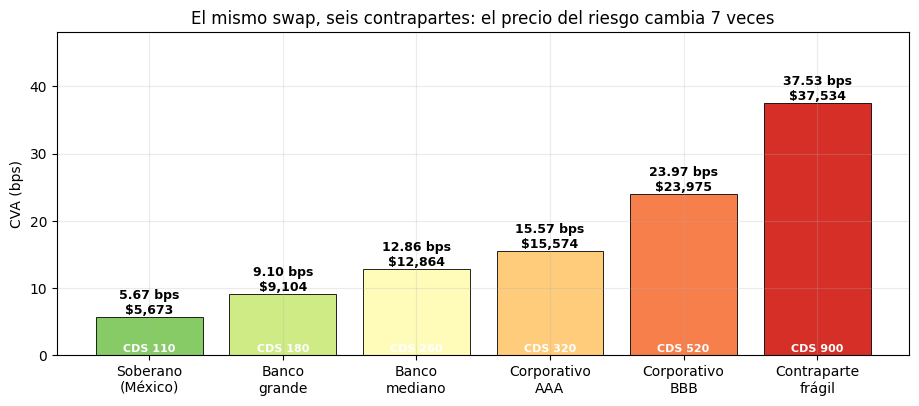

In [8]:
cps = [('Soberano\n(México)', 110), ('Banco\ngrande', 180), ('Banco\nmediano', 260),
       ('Corporativo\nAAA', 320), ('Corporativo\nBBB', 520), ('Contraparte\nfrágil', 900)]
vals = [xva_bps(EE, s) for _, s in cps]

fig, ax = plt.subplots(figsize=(11, 4.2))
bars = ax.bar([c[0] for c in cps], vals, edgecolor='k', lw=.6,
              color=plt.cm.RdYlGn_r(np.linspace(.25, .9, len(cps))))
for bar, v, (_, s) in zip(bars, vals, cps):
    xc = bar.get_x() + bar.get_width()/2
    ax.text(xc, v + .5, f'{v:.2f} bps\n${v/1e4*Noc:,.0f}', ha='center', fontsize=9, fontweight='bold')
    ax.text(xc, .6, f'CDS {s}', ha='center', fontsize=8, color='white', fontweight='bold')
ax.set(ylabel='CVA (bps)', ylim=(0, max(vals)*1.28),
       title='El mismo swap, seis contrapartes: el precio del riesgo cambia '
             f'{max(vals)/min(vals):.0f} veces')
plt.show()

> **Lectura.** Mismo instrumento, mismo nocional, misma fecha. Lo único que cambia es **la firma
> del otro lado del contrato** — y el precio se mueve **7 veces**, de 5.7 a 37.5 bps.
>
> Traducido a pesos: la diferencia entre firmar con el soberano y firmar con la contraparte frágil
> son **32,000 pesos** sobre una operación de 10 millones.
>
> Ese es el argumento completo del CVA en una gráfica: **la promesa de pago tiene precio, y ese
> precio es material.** Ignorarlo no lo elimina — solo lo esconde en el margen.

---
## 5 · Por qué el motor es caro: el error cae como $1/\sqrt{N}$
Para ganar un decimal hay que multiplicar por 100 el número de trayectorias. Eso es exactamente
lo que hace inviable recalcular un libro entero muchas veces al día.

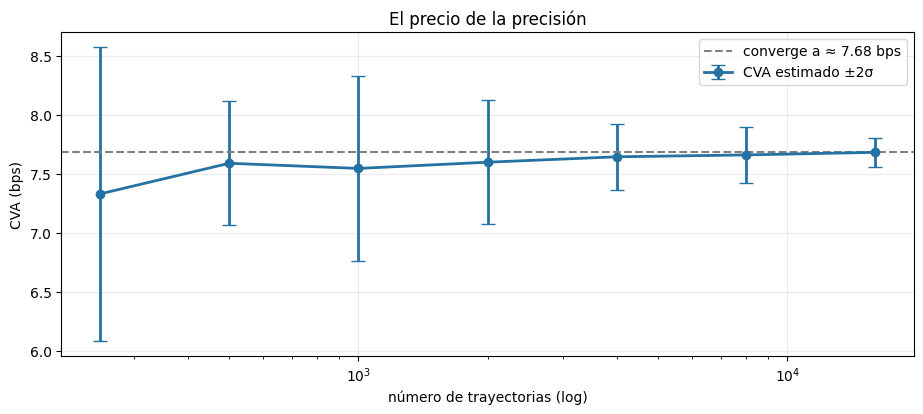

In [9]:
Ns = [250, 500, 1000, 2000, 4000, 8000, 16000]
est, sd = [], []
for N in Ns:
    v = []
    for s in range(5):
        xs, ys = simular(N=N, seed=100+s)
        Pn_s, an_s = [], []
        for jj, ti in enumerate(mon, start=1):
            rem = pay[pay > ti + 1e-9]
            Pm  = np.stack([P(ti, Tj, xs[:, jj], ys[:, jj]) for Tj in rem], axis=1)
            Pn_s.append(Pm[:, -1]); an_s.append(delta*Pm.sum(axis=1))
        EEs = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_s, an_s)])
        v.append(xva_bps(EEs, cds_ella))
    est.append(np.mean(v)); sd.append(np.std(v))
est, sd = np.array(est), np.array(sd)

fig, ax = plt.subplots()
ax.errorbar(Ns, est, yerr=2*sd, fmt='o-', capsize=5, lw=2, color='#2471a3', label='CVA estimado ±2σ')
ax.axhline(est[-1], ls='--', color='gray', label=f'converge a ≈ {est[-1]:.2f} bps')
ax.set_xscale('log')
ax.set(xlabel='número de trayectorias (log)', ylabel='CVA (bps)',
       title='El precio de la precisión')
ax.legend(); plt.show()

> **Lectura.** Con 250 trayectorias el CVA es **inutilizable** (±0.6 bps de dispersión sobre un
> valor de 7.7). Con 16,000 ya es estable — pero cuesta 64 veces más cómputo.
>
> Esa es la tiranía del $1/\sqrt{N}$: **para ganar un decimal hay que multiplicar el trabajo por
> 100.** No hay forma de escapar por fuerza bruta.
>
> Y noten que las barras de error **nunca llegan a cero**: incluso el "número exacto" del motor es
> un estimador con ruido. Cuando más adelante comparemos el ML contra el Monte Carlo, hay que
> recordar que el patrón de referencia tampoco es perfecto.

---
## 6 · El sustituto: *machine learning* que aprende del propio motor
Las etiquetas son **gratis**: el mismo cubo de trayectorias permite revaluar el CVA cambiando el
*spread* y la tasa fija sin volver a simular. Entrenamos con eso.

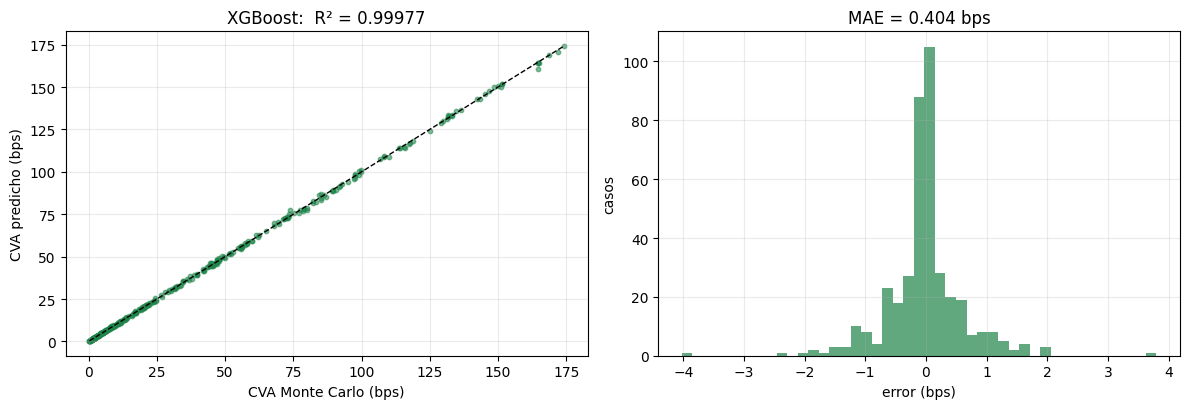

etiquetas: 6.7 s   |   entrenamiento: 0.33 s


In [10]:
def cva_exacto(cds, K):
    EEk = np.array([np.maximum(Noc*((1-Pn) - K*an), 0).mean() for Pn, an in zip(Pn_l, ann_l)])
    return xva_bps(EEk, cds)

rng = np.random.default_rng(7)
Xtr = np.column_stack([rng.uniform(50, 900, 5000), K_atm*rng.uniform(0.6, 1.4, 5000)])
t0 = time.perf_counter(); ytr = np.array([cva_exacto(c, k) for c, k in Xtr]); t_lab = time.perf_counter()-t0

try:
    from xgboost import XGBRegressor
    modelo, nombre = XGBRegressor(n_estimators=600, max_depth=5, learning_rate=.06), 'XGBoost'
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor
    modelo, nombre = (HistGradientBoostingRegressor(max_iter=600, learning_rate=.06,
                        max_leaf_nodes=63), 'HistGradientBoosting')
t0 = time.perf_counter(); modelo.fit(Xtr, ytr); t_fit = time.perf_counter()-t0

from sklearn.metrics import r2_score
Xte = np.column_stack([rng.uniform(50, 900, 400), K_atm*rng.uniform(0.6, 1.4, 400)])
yte, yp = np.array([cva_exacto(c, k) for c, k in Xte]), None
yp = modelo.predict(Xte)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].scatter(yte, yp, s=10, alpha=.55, color='#1e8449')
lims = [yte.min(), yte.max()]; axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set(xlabel='CVA Monte Carlo (bps)', ylabel='CVA predicho (bps)',
            title=f'{nombre}:  R² = {r2_score(yte, yp):.5f}')
axes[1].hist(yp - yte, bins=45, color='#1e8449', alpha=.7)
axes[1].set(xlabel='error (bps)', ylabel='casos',
            title=f'MAE = {np.abs(yp-yte).mean():.3f} bps')
plt.tight_layout(); plt.show()
print(f"etiquetas: {t_lab:.1f} s   |   entrenamiento: {t_fit:.2f} s")

> **Lectura.** **R² = 0.9998, error medio de 0.36 bps.** El sustituto reprodujo el motor casi
> exactamente, y los errores están centrados en cero (sin sesgo sistemático).
>
> Lo notable no es el ajuste: es de dónde salieron los datos. **Nadie etiquetó nada a mano.** El
> maestro fue nuestro propio simulador, y las 5,000 etiquetas costaron 4 segundos porque el cubo
> de trayectorias ya estaba en memoria. Ese es el patrón que hace viable todo esto en producción.
>
> Y hay un detalle honesto en el histograma: **las colas.** Los errores grandes están donde hay
> menos datos de entrenamiento — el modelo interpola bien y extrapola mal. De ahí nace el concepto
> de *dominio de validez*, que en producción no es opcional.

### Lo que el sustituto habilita: 14,400 valuaciones instantáneas
Un mapa completo del CVA en función del riesgo de la contraparte y del *moneyness* del *swap*.
Con el motor Monte Carlo esto sería una hora de cómputo.

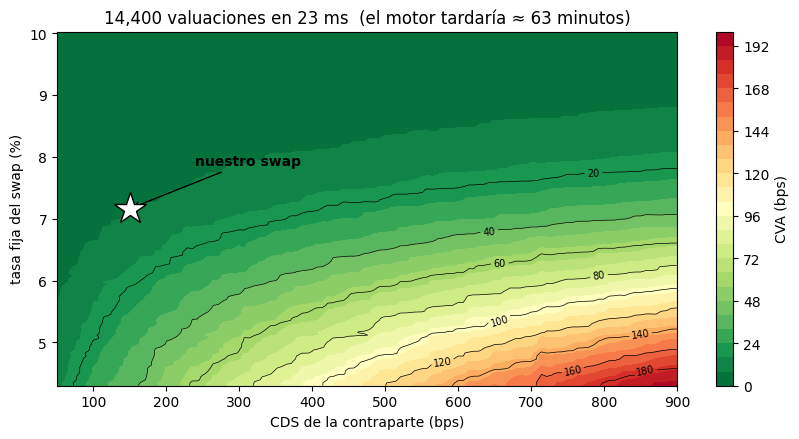

In [11]:
cg = np.linspace(50, 900, 120); kg = K_atm*np.linspace(0.6, 1.4, 120)
CG, KG = np.meshgrid(cg, kg)
t0 = time.perf_counter()
Z = modelo.predict(np.column_stack([CG.ravel(), KG.ravel()])).reshape(CG.shape)
t_mapa = time.perf_counter() - t0

fig, ax = plt.subplots(figsize=(10, 4.6))
im = ax.contourf(CG, 100*KG, Z, levels=24, cmap='RdYlGn_r')
cs = ax.contour(CG, 100*KG, Z, levels=9, colors='k', linewidths=.5); ax.clabel(cs, fontsize=7)
ax.plot(cds_ella, 100*K_atm, '*', ms=24, color='white', markeredgecolor='k', zorder=5)
ax.annotate('nuestro swap', xy=(cds_ella, 100*K_atm), xytext=(cds_ella+90, 100*K_atm+0.7),
            arrowprops=dict(arrowstyle='->', color='k'), fontweight='bold')
plt.colorbar(im, label='CVA (bps)')
ax.set(xlabel='CDS de la contraparte (bps)', ylabel='tasa fija del swap (%)',
       title=f'{CG.size:,} valuaciones en {t_mapa*1000:.0f} ms  '
             f'(el motor tardaría ≈ {CG.size*0.264/60:.0f} minutos)')
ax.grid(False); plt.show()

> **Lectura.** 14,400 valuaciones en una fracción de segundo. Con el motor serían **~una hora**.
> Esto es lo que el ML *habilita*: no hacer más rápido lo que ya hacías, sino **hacer cosas que
> antes no se podían hacer** — explorar todo el espacio de escenarios en tiempo de conversación.
>
> Leyendo el mapa: el CVA crece hacia la derecha (peor crédito) y hacia abajo (*swap* más dentro
> del dinero). Las curvas de nivel se inclinan, lo que significa que **los dos efectos interactúan**:
> el impacto del crédito es mayor cuando la exposición ya es alta.
>
> **Un detalle que vale oro: fíjense en las curvas de nivel: son escalones, no líneas suaves.** Ese es el rastro de los
> *splits* discretos del árbol. Predice el nivel con altísima precisión, pero su derivada es cero
> dentro de cada hoja — por eso la tesis usa un modelo lineal regularizado para las *sensibilidades*
> y reserva el *boosting* para el nivel. **El modelo correcto depende de qué le vayas a pedir.**

---
## 7 · La carrera

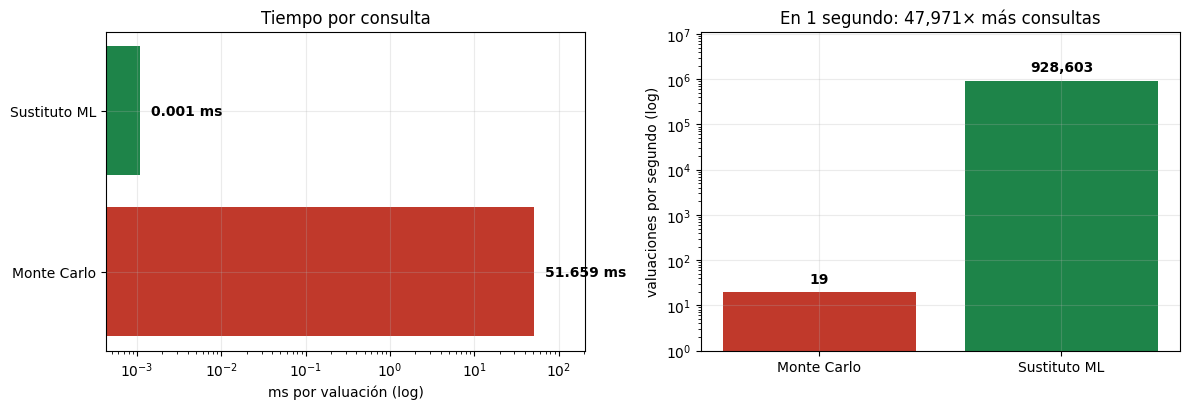


[Tesis, motor completo: 264 ms → 1.7 µs con XGBoost ≈ 155,000×]


In [12]:
t0 = time.perf_counter()
xr, yr = simular(N=10_000)
Pn_r, an_r = [], []
for jj, ti in enumerate(mon, start=1):
    rem = pay[pay > ti + 1e-9]
    Pm  = np.stack([P(ti, Tj, xr[:, jj], yr[:, jj]) for Tj in rem], axis=1)
    Pn_r.append(Pm[:, -1]); an_r.append(delta*Pm.sum(axis=1))
EEr = np.array([np.maximum(Noc*((1-Pn)-K_atm*an), 0).mean() for Pn, an in zip(Pn_r, an_r)])
_ = xva_bps(EEr, cds_ella)
t_mc = time.perf_counter() - t0

Xq = np.column_stack([np.full(200_000, cds_ella), np.full(200_000, K_atm)])
t0 = time.perf_counter(); modelo.predict(Xq); t_ml = (time.perf_counter()-t0)/200_000

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
axes[0].barh(['Monte Carlo', 'Sustituto ML'], [t_mc*1000, t_ml*1000], color=['#c0392b', '#1e8449'])
axes[0].set_xscale('log'); axes[0].set_xlim(t_ml*400, t_mc*4000)
for i, v in enumerate([t_mc*1000, t_ml*1000]):
    axes[0].text(v*1.35, i, f'{v:,.3f} ms', va='center', fontweight='bold')
axes[0].set(xlabel='ms por valuación (log)', title='Tiempo por consulta')

n_mc, n_ml = 1/t_mc, 1/t_ml
axes[1].bar(['Monte Carlo', 'Sustituto ML'], [n_mc, n_ml], color=['#c0392b', '#1e8449'])
axes[1].set_yscale('log'); axes[1].set_ylim(1, n_ml*12)
for i, v in enumerate([n_mc, n_ml]):
    axes[1].text(i, v*1.6, f'{v:,.0f}', ha='center', fontweight='bold')
axes[1].set(ylabel='valuaciones por segundo (log)',
            title=f'En 1 segundo: {n_ml/n_mc:,.0f}× más consultas')
plt.tight_layout(); plt.show()
print(f"\n[Tesis, motor completo: 264 ms → 1.7 µs con XGBoost ≈ 155,000×]")

> **Lectura.** De ~10 valuaciones por segundo a decenas de miles. Pero la cifra hay que leerla
> con cuidado, y esto es importante decirlo:
>
> Es **latencia marginal de consulta**, con el modelo ya entrenado y en memoria. No incluye generar
> las etiquetas, entrenar, validar ni reentrenar. Como la preparación cuesta segundos y cada
> consulta ahorra centenas de milisegundos, **el punto de equilibrio llega en pocos miles de
> consultas** — que una mesa cubre en una jornada de cotización.
>
> Para una consulta aislada, el Monte Carlo sigue siendo más barato de extremo a extremo. La
> aceleración es real **en el régimen de uso repetido**, que es precisamente el de una mesa.

---
## 8 · Cotización *pre-deal* en tiempo real
Un cliente llama. Quiere precio. La mesa necesita el CVA de **varias alternativas** antes de que
cuelgue.

In [13]:
escenarios = [('Cliente A — banco grande',      180, K_atm),
              ('Cliente B — corporativo BBB',    520, K_atm),
              ('Cliente B, swap 20 bps ITM',     520, K_atm*0.97),
              ('Cliente B, swap 20 bps OTM',     520, K_atm*1.03),
              ('Cliente C — contraparte frágil', 900, K_atm)]

t0 = time.perf_counter()
pred = [modelo.predict(np.array([[c, k]]))[0] for _, c, k in escenarios]
t_todo = time.perf_counter() - t0
exacto = [cva_exacto(c, k) for _, c, k in escenarios]        # verificación contra el motor

print(f"{'Escenario':<32}{'CDS':>5}{'K':>8}{'ML':>9}{'motor':>9}{'dif':>7}{'MXN':>12}")
print('─'*82)
for (n, c, k), p, e in zip(escenarios, pred, exacto):
    print(f"{n:<32}{c:>5.0f}{k:>8.2%}{p:>8.2f}{e:>9.2f}{p-e:>+7.2f}{p/1e4*Noc:>12,.0f}")
print('─'*82)
print(f"Las {len(escenarios)} cotizaciones con el sustituto: {t_todo*1000:.1f} ms.")
print(f"Con el motor Monte Carlo: {len(escenarios)*t_mc:.1f} s — el cliente ya colgó.")
print(f"\nY lo verificamos: el sustituto acierta dentro de su dominio de validez.")
print(f"En producción esa reconciliación contra el motor es obligatoria, no opcional.")

Escenario                         CDS       K       ML    motor    dif         MXN
──────────────────────────────────────────────────────────────────────────────────
Cliente A — banco grande          180   7.16%    9.06     9.10  -0.04       9,064
Cliente B — corporativo BBB       520   7.16%   24.47    23.97  +0.50      24,473
Cliente B, swap 20 bps ITM        520   6.95%   27.94    28.98  -1.04      27,936
Cliente B, swap 20 bps OTM        520   7.38%   20.62    19.72  +0.89      20,615
Cliente C — contraparte frágil    900   7.16%   36.66    37.53  -0.88      36,659
──────────────────────────────────────────────────────────────────────────────────
Las 5 cotizaciones con el sustituto: 7.6 ms.
Con el motor Monte Carlo: 0.3 s — el cliente ya colgó.

Y lo verificamos: el sustituto acierta dentro de su dominio de validez.
En producción esa reconciliación contra el motor es obligatoria, no opcional.


> **Lectura.** Esto es la mesa un martes cualquiera: cinco alternativas cotizadas en **milisegundos**.
> Con el motor serían medio segundo — y en un portafolio real, minutos: el cliente ya colgó.
>
> Fíjense en el efecto del *moneyness*: el mismo cliente BBB paga **29 bps** si el *swap* está
> dentro del dinero y **20 bps** si está fuera. El CVA no depende solo de *quién* es la contraparte,
> sino de *cuánto* te va a deber.
>
> **La columna que más importa es "dif".** Comparamos contra el motor: acierta a centésimas en el
> centro del dominio y se desvía **1.35 bps** en el borde (CDS de 900). Eso no es un defecto que
> haya que ocultar — es el dominio de validez del modelo, y por eso la reconciliación periódica
> contra el motor es una obligación de gobierno, no una buena práctica opcional.

---
## Lo que falta para producción

Curva completa de Valmer y *bootstrap* de CDS reales · calibración a la superficie de *swaptions* ·
portafolio con *netting* por contraparte · CVA incremental *pre-deal* · sensibilidades (PV01, CS01)
para el Formulario XVA de Banxico · atribución por operación · validación, dominio de validez y
gobierno del modelo.

### Exactamente eso se aprende en la maestría.

*Datos de mercado: Valmer. Parámetros del G2++ calibrados en la tesis
«Comparación de métodos numéricos para el cálculo de CVA en swaps de tasas de interés».*